# 01 — Análisis Exploratorio de Datos (EDA)

**Objetivo:** Explorar el dataset limpio (`leads_cleaned.csv`) para descubrir patrones, relaciones y anomalías antes de construir el modelo predictivo.

**¿Qué es un EDA y por qué es necesario?**  
Antes de entrenar un modelo, necesitamos **entender los datos**. Un EDA responde preguntas como:
- ¿Cómo está distribuido el target? ¿Hay desbalance?
- ¿Qué features parecen tener relación con el target?
- ¿Hay categorías con muy pocos registros que podrían generar ruido?
- ¿Existen patrones temporales (hora, día, mes) que influyan en la conversión?

**Análisis incluidos:**
1. Carga y resumen general del dataset
2. Distribución del target (Hot vs Cold)
3. Análisis de features numéricas (temporales)
4. Análisis de features categóricas
5. Tasa de conversión por feature (relación feature → target)
6. Análisis temporal detallado (heatmaps hora×día)
7. Análisis de volumen vs conversión
8. Correlaciones entre features numéricas
9. Detección de categorías de baja frecuencia
10. Hallazgos clave y recomendaciones para el modelado

## 1. Importar librerías y cargar dataset limpio

Usamos el dataset que generamos en `00_data_engineering.ipynb`. Ya está limpio: sin nulos, sin duplicados, con el target binario creado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

CLEAN_PATH = "../data/processed/leads_cleaned.csv"
df = pd.read_csv(CLEAN_PATH)

print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes.to_string())

Dataset cargado: 8,422 filas x 14 columnas

Columnas: ['anio_creacion', 'mes_creacion', 'dia_creacion', 'hora_creacion', 'dia_semana_creacion', 'nombre_formulario', 'campana', 'plataforma', 'origen_creacion', 'subtipo_interes', 'vehiculo_interes', 'concesion', 'origen', 'target']

Tipos de datos:
anio_creacion           int64
mes_creacion            int64
dia_creacion            int64
hora_creacion           int64
dia_semana_creacion    object
nombre_formulario      object
campana                object
plataforma             object
origen_creacion        object
subtipo_interes        object
vehiculo_interes       object
concesion              object
origen                 object
target                  int64


In [2]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print("\n--- Numéricas ---")
print(df.describe().to_string())
print("\n--- Categóricas ---")
print(df.describe(include='object').to_string())

=== ESTADÍSTICAS DESCRIPTIVAS ===

--- Numéricas ---
       anio_creacion  mes_creacion  dia_creacion  hora_creacion       target
count    8422.000000   8422.000000   8422.000000    8422.000000  8422.000000
mean     2025.245072      9.304203     19.409998      13.573617     0.686535
std         0.430156      4.731712      9.480605       6.658033     0.463929
min      2025.000000      1.000000      1.000000       0.000000     0.000000
25%      2025.000000     12.000000     18.000000      10.000000     0.000000
50%      2025.000000     12.000000     22.000000      14.000000     1.000000
75%      2025.000000     12.000000     26.000000      19.000000     1.000000
max      2026.000000     12.000000     31.000000      23.000000     1.000000

--- Categóricas ---
       dia_semana_creacion nombre_formulario      campana              plataforma origen_creacion      subtipo_interes vehiculo_interes    concesion       origen
count                 8422              8422         8422              

## 2. Distribución del target (Hot vs Cold)

Lo primero que debemos verificar es **qué tan balanceado está el target**. Si una clase domina mucho (>80%), el modelo puede aprender a "predecir siempre lo mismo" y tener accuracy alto sin realmente aprender patrones.

**Regla general:**
- 50/50 → Perfectamente balanceado (raro en la realidad)
- 60/40 a 70/30 → Desbalance leve, manejable
- 80/20 o peor → Desbalance significativo, requiere técnicas especiales (SMOTE, class_weight, etc.)

=== DISTRIBUCIÓN DEL TARGET ===

  1 (Hot Lead):   5,782 (68.7%)
  0 (Cold Lead):  2,640 (31.3%)
  Total:          8,422

  Ratio Hot/Cold: 2.19:1

  Desbalance leve. No se requieren técnicas especiales.


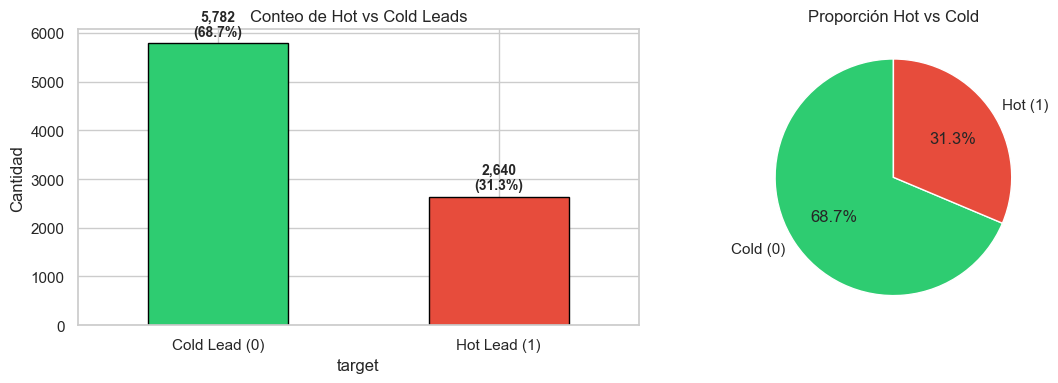

In [3]:
hot = df["target"].sum()
cold = len(df) - hot
total = len(df)
ratio = hot / cold

print("=== DISTRIBUCIÓN DEL TARGET ===\n")
print(f"  1 (Hot Lead):   {hot:,} ({hot/total*100:.1f}%)")
print(f"  0 (Cold Lead):  {cold:,} ({cold/total*100:.1f}%)")
print(f"  Total:          {total:,}")
print(f"\n  Ratio Hot/Cold: {ratio:.2f}:1")

if hot/total > 0.8 or cold/total > 0.8:
    print("\n  ADVERTENCIA: Desbalance significativo (>80/20). Considerar SMOTE o class_weight.")
elif hot/total > 0.7 or cold/total > 0.7:
    print("\n  NOTA: Desbalance moderado (~70/30). Monitorear métricas por clase (recall, precision).")
else:
    print("\n  Desbalance leve. No se requieren técnicas especiales.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["target"].value_counts()
bars = counts.plot(kind="bar", color=["#2ecc71", "#e74c3c"], edgecolor="black", ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Cold Lead (0)", "Hot Lead (1)"], rotation=0)
axes[0].set_title("Conteo de Hot vs Cold Leads")
axes[0].set_ylabel("Cantidad")

for i, (val, cnt) in enumerate(counts.items()):
    pct = cnt / total * 100
    axes[0].text(i, cnt + total*0.01, f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold", fontsize=10)

df["target"].value_counts().plot(kind="pie", colors=["#2ecc71", "#e74c3c"],
                                  autopct="%1.1f%%", labels=["Cold (0)", "Hot (1)"],
                                  startangle=90, ax=axes[1])
axes[1].set_title("Proporción Hot vs Cold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Análisis de features numéricas (temporales)

Nuestras features numéricas son todas **temporales** (derivadas de la fecha de creación del lead). A diferencia de features continuas como precio o superficie, estas representan ciclos (horas, días, meses).

Preguntas clave:
- **¿A qué hora llegan más leads?** ¿Y a qué hora convierten más?
- **¿Qué día del mes es más activo?**
- **¿Hay estacionalidad mensual?**

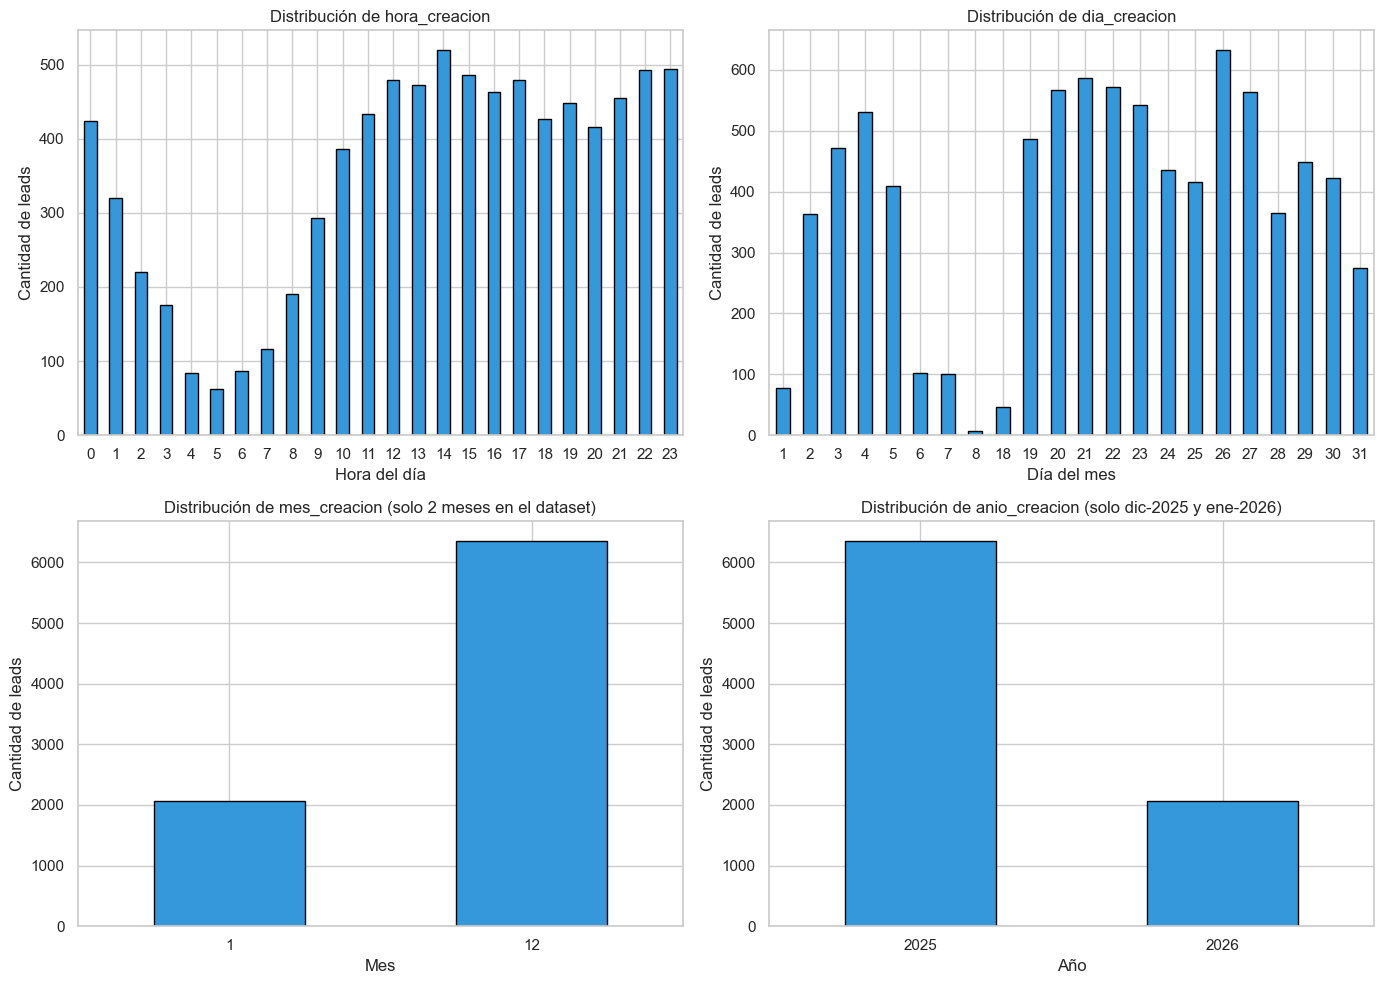

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["hora_creacion"].value_counts().sort_index().plot(kind="bar", color="#3498db", edgecolor="black", ax=axes[0, 0])
axes[0, 0].set_title("Distribución de hora_creacion")
axes[0, 0].set_xlabel("Hora del día")
axes[0, 0].set_ylabel("Cantidad de leads")
axes[0, 0].tick_params(axis='x', rotation=0)

df["dia_creacion"].value_counts().sort_index().plot(kind="bar", color="#3498db", edgecolor="black", ax=axes[0, 1])
axes[0, 1].set_title("Distribución de dia_creacion")
axes[0, 1].set_xlabel("Día del mes")
axes[0, 1].set_ylabel("Cantidad de leads")
axes[0, 1].tick_params(axis='x', rotation=0)

df["mes_creacion"].value_counts().sort_index().plot(kind="bar", color="#3498db", edgecolor="black", ax=axes[1, 0])
axes[1, 0].set_title("Distribución de mes_creacion (solo 2 meses en el dataset)")
axes[1, 0].set_xlabel("Mes")
axes[1, 0].set_ylabel("Cantidad de leads")
axes[1, 0].tick_params(axis='x', rotation=0)

df["anio_creacion"].value_counts().sort_index().plot(kind="bar", color="#3498db", edgecolor="black", ax=axes[1, 1])
axes[1, 1].set_title("Distribución de anio_creacion (solo dic-2025 y ene-2026)")
axes[1, 1].set_xlabel("Año")
axes[1, 1].set_ylabel("Cantidad de leads")
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 3.1 Distribución por hora del día — Hot vs Cold

Comparamos cómo se distribuyen los leads **Hot** y **Cold** a lo largo del día. Si hay franjas horarias donde la tasa de conversión es muy diferente, la hora será una feature importante para el modelo.

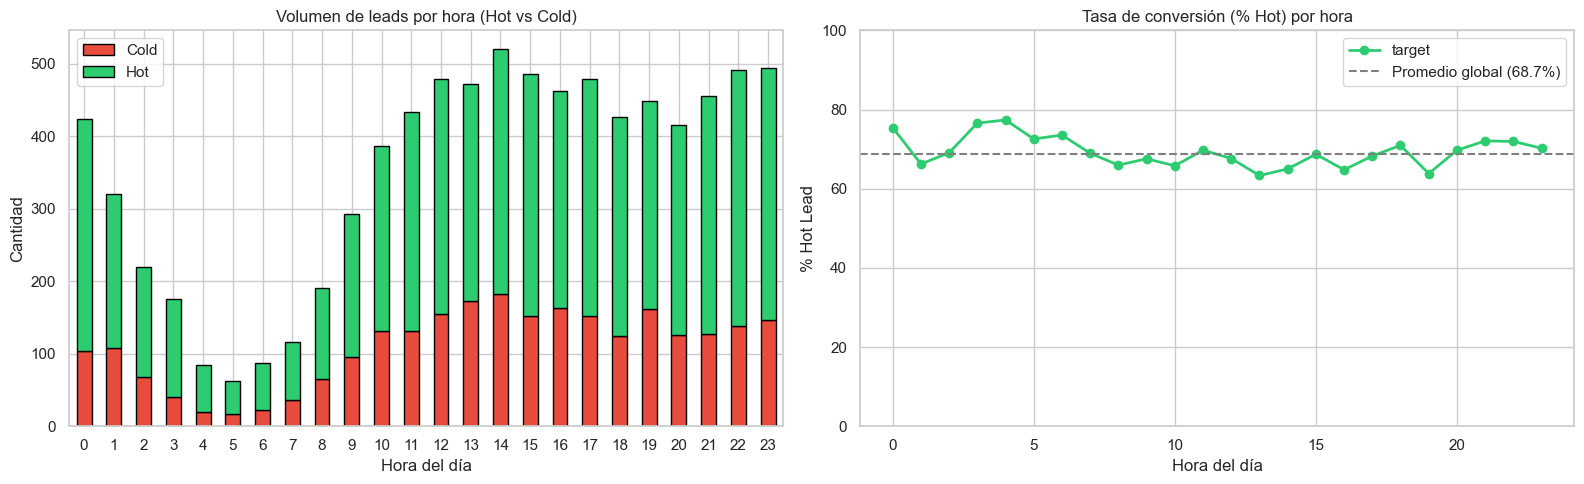


Top 5 horas con MAYOR conversión:
  Hora 04:00 → 77.4% Hot (84 leads)
  Hora 03:00 → 76.6% Hot (175 leads)
  Hora 00:00 → 75.5% Hot (424 leads)
  Hora 06:00 → 73.6% Hot (87 leads)
  Hora 05:00 → 72.6% Hot (62 leads)

Top 5 horas con MENOR conversión:
  Hora 13:00 → 63.3% Hot (472 leads)
  Hora 19:00 → 63.8% Hot (448 leads)
  Hora 16:00 → 64.8% Hot (463 leads)
  Hora 14:00 → 65.0% Hot (520 leads)
  Hora 10:00 → 65.8% Hot (386 leads)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hora_target = df.groupby(["hora_creacion", "target"]).size().unstack(fill_value=0)
hora_target.columns = ["Cold", "Hot"]
hora_target.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], edgecolor="black", ax=axes[0])
axes[0].set_title("Volumen de leads por hora (Hot vs Cold)")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=0)

conv_hora = df.groupby("hora_creacion")["target"].mean() * 100
conv_hora.plot(kind="line", marker="o", color="#2ecc71", linewidth=2, ax=axes[1])
axes[1].axhline(y=df["target"].mean()*100, color="gray", linestyle="--", label=f"Promedio global ({df['target'].mean()*100:.1f}%)")
axes[1].set_title("Tasa de conversión (% Hot) por hora")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("% Hot Lead")
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nTop 5 horas con MAYOR conversión:")
for hora, pct in conv_hora.nlargest(5).items():
    vol = len(df[df['hora_creacion']==hora])
    print(f"  Hora {hora:02d}:00 → {pct:.1f}% Hot ({vol} leads)")

print("\nTop 5 horas con MENOR conversión:")
for hora, pct in conv_hora.nsmallest(5).items():
    vol = len(df[df['hora_creacion']==hora])
    print(f"  Hora {hora:02d}:00 → {pct:.1f}% Hot ({vol} leads)")

### 3.2 Distribución por día de la semana

¿Los leads que llegan en fin de semana tienen un comportamiento diferente a los de días laborales?

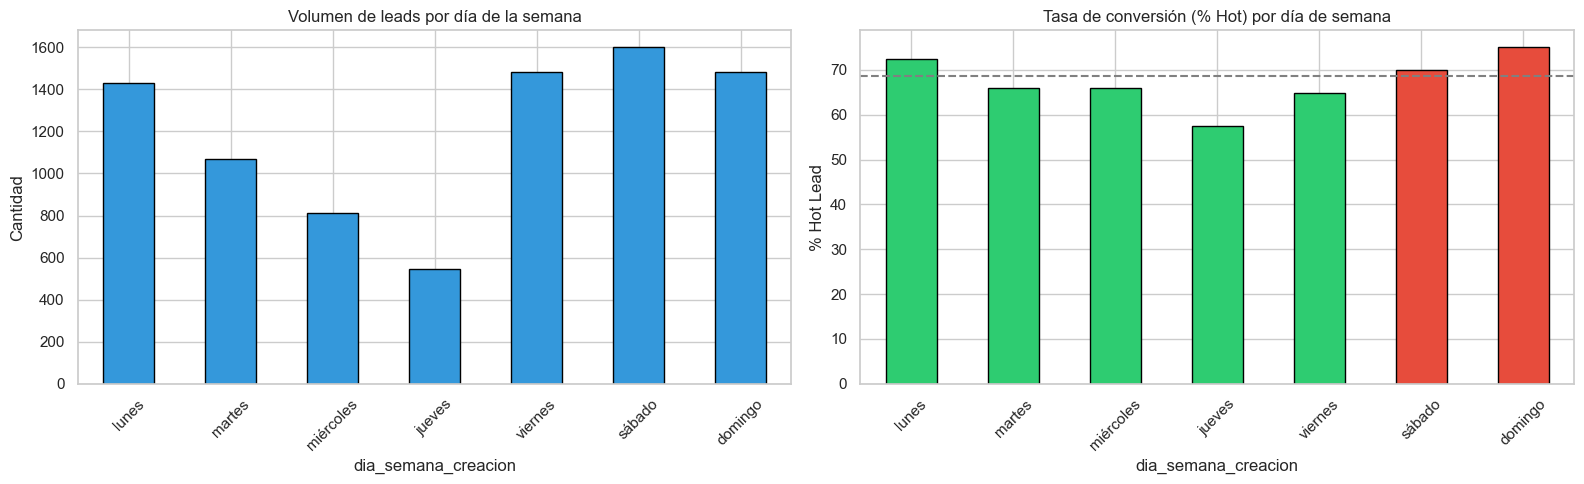

Conversión por día:
  lunes        (laboral)          → 72.5% Hot  (1,430 leads)
  martes       (laboral)          → 65.9% Hot  (1,067 leads)
  miércoles    (laboral)          → 65.9% Hot  (812 leads)
  jueves       (laboral)          → 57.5% Hot  (546 leads)
  viernes      (laboral)          → 64.8% Hot  (1,484 leads)
  sábado       (fin de semana)    → 69.9% Hot  (1,600 leads)
  domingo      (fin de semana)    → 75.1% Hot  (1,483 leads)


In [6]:
orden_dias = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
dias_presentes = [d for d in orden_dias if d in df["dia_semana_creacion"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dia_counts = df["dia_semana_creacion"].value_counts().reindex(dias_presentes)
dia_counts.plot(kind="bar", color="#3498db", edgecolor="black", ax=axes[0])
axes[0].set_title("Volumen de leads por día de la semana")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=45)

conv_dia = df.groupby("dia_semana_creacion")["target"].mean().reindex(dias_presentes) * 100
colors = ["#e74c3c" if d in ["sábado", "domingo"] else "#2ecc71" for d in dias_presentes]
conv_dia.plot(kind="bar", color=colors, edgecolor="black", ax=axes[1])
axes[1].axhline(y=df["target"].mean()*100, color="gray", linestyle="--")
axes[1].set_title("Tasa de conversión (% Hot) por día de semana")
axes[1].set_ylabel("% Hot Lead")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Conversión por día:")
for dia in dias_presentes:
    vol = len(df[df['dia_semana_creacion']==dia])
    pct = df[df['dia_semana_creacion']==dia]['target'].mean()*100
    tipo = "(fin de semana)" if dia in ["sábado", "domingo"] else "(laboral)"
    print(f"  {dia:12s} {tipo:18s} → {pct:.1f}% Hot  ({vol:,} leads)")

### 3.3 Distribución por mes

¿Hay meses con mayor volumen o mejor conversión? Esto puede revelar **estacionalidad** en el negocio.

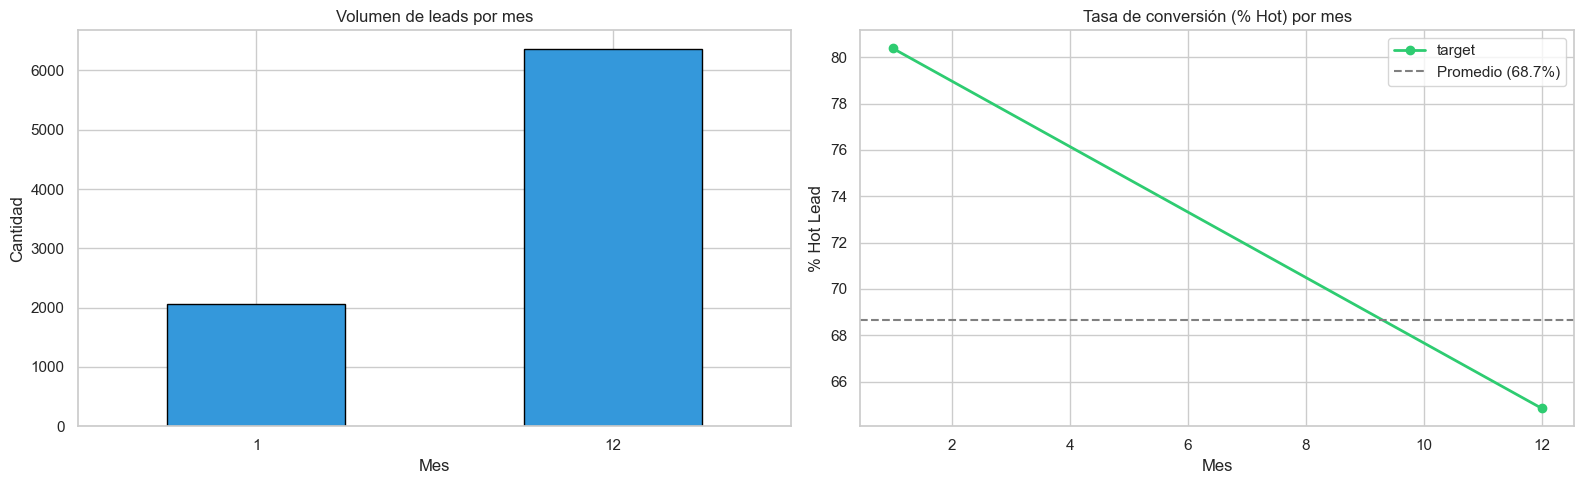

Detalle por mes:
  Mes  1 → 80.4% Hot  (2,064 leads)
  Mes 12 → 64.8% Hot  (6,358 leads)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mes_counts = df["mes_creacion"].value_counts().sort_index()
mes_counts.plot(kind="bar", color="#3498db", edgecolor="black", ax=axes[0])
axes[0].set_title("Volumen de leads por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=0)

conv_mes = df.groupby("mes_creacion")["target"].mean() * 100
conv_mes.plot(kind="line", marker="o", color="#2ecc71", linewidth=2, ax=axes[1])
axes[1].axhline(y=df["target"].mean()*100, color="gray", linestyle="--", label=f"Promedio ({df['target'].mean()*100:.1f}%)")
axes[1].set_title("Tasa de conversión (% Hot) por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("% Hot Lead")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Detalle por mes:")
for mes in sorted(df["mes_creacion"].unique()):
    vol = len(df[df['mes_creacion']==mes])
    pct = df[df['mes_creacion']==mes]['target'].mean()*100
    print(f"  Mes {mes:2d} → {pct:.1f}% Hot  ({vol:,} leads)")

### 3.4 Conclusiones del análisis temporal

**Ventana de datos limitada:** El dataset solo cubre **2 meses** (diciembre 2025 y enero 2026). Esto explica por qué los gráficos de año y mes solo muestran 2 barras. No es un error — es la ventana de datos exportada del CRM. Implicancia: no podemos analizar estacionalidad anual real, pero sí patrones de hora y día de semana.

**Hallazgos clave:**

1. **Hora del día importa:** Los leads de madrugada (00:00-06:00) tienen la mayor tasa de conversión (~73-77%), mientras que los de horario laboral (10:00-16:00) convierten menos (~63-65%). Posible explicación: quien llena un formulario de madrugada tiene un interés más genuino.

2. **Día de la semana importa:** Domingo es el mejor día (75.1% Hot) y jueves el peor (57.5% Hot). En general, fin de semana supera a días laborales. Los leads de fin de semana tienden a ser personas con más tiempo y decisión.

3. **Mes:** Enero 2026 tiene mucha mayor conversión (80.4%) que diciembre 2025 (64.8%). Esto tiene una explicación de negocio: en diciembre muchos compradores **esperan a enero para que la patente del vehículo quede registrada con el año siguiente**, lo cual mejora el valor de reventa. Por eso en diciembre hay más leads "exploratorios" (Cold) y en enero llegan los que ya decidieron comprar (Hot). Con solo 2 meses no podemos confirmar si es un patrón anual, pero la lógica comercial lo respalda.

4. **Día del mes:** La distribución es relativamente uniforme, sin un patrón claro de quincena o fin de mes.

**Recomendación para el modelo:** `hora_creacion` y `dia_semana_creacion` serán features relevantes. `anio_creacion` aporta muy poca variabilidad (casi todo es 2025), podría considerarse eliminarla en feature engineering.

## 4. Análisis de features categóricas

Tenemos 9 features categóricas con diferente cardinalidad (cantidad de valores únicos):
- **Baja** (2-5 valores): `plataforma`, `origen_creacion`, `subtipo_interes`
- **Media** (15-23 valores): `nombre_formulario`, `vehiculo_interes`, `origen`, `campana`
- **Alta** (93 valores): `concesion`

Analizamos la distribución de cada una para detectar categorías dominantes, desbalances y posibles agrupaciones.

### 4.1 Features de baja cardinalidad

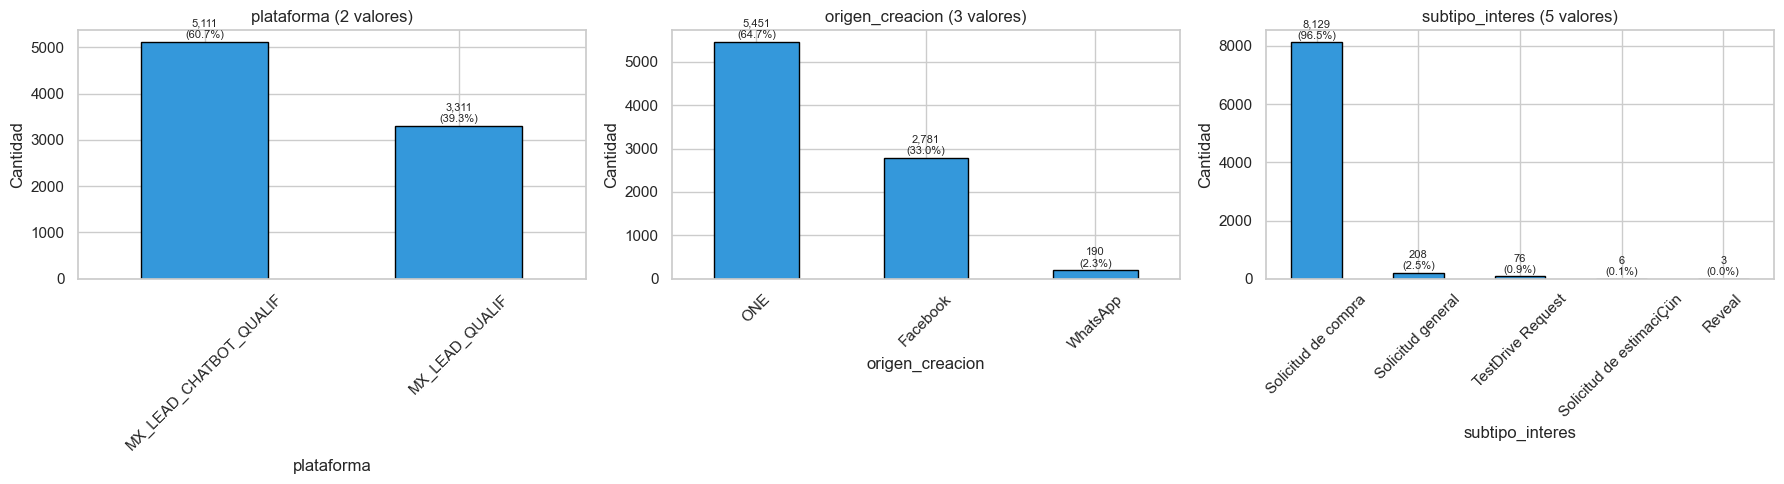

In [8]:
low_card = ["plataforma", "origen_creacion", "subtipo_interes"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, low_card):
    vc = df[col].value_counts()
    vc.plot(kind="bar", color="#3498db", edgecolor="black", ax=ax)
    ax.set_title(f"{col} ({len(vc)} valores)")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis='x', rotation=45)
    for i, (val, cnt) in enumerate(vc.items()):
        ax.text(i, cnt + len(df)*0.005, f"{cnt:,}\n({cnt/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### 4.2 Features de cardinalidad media

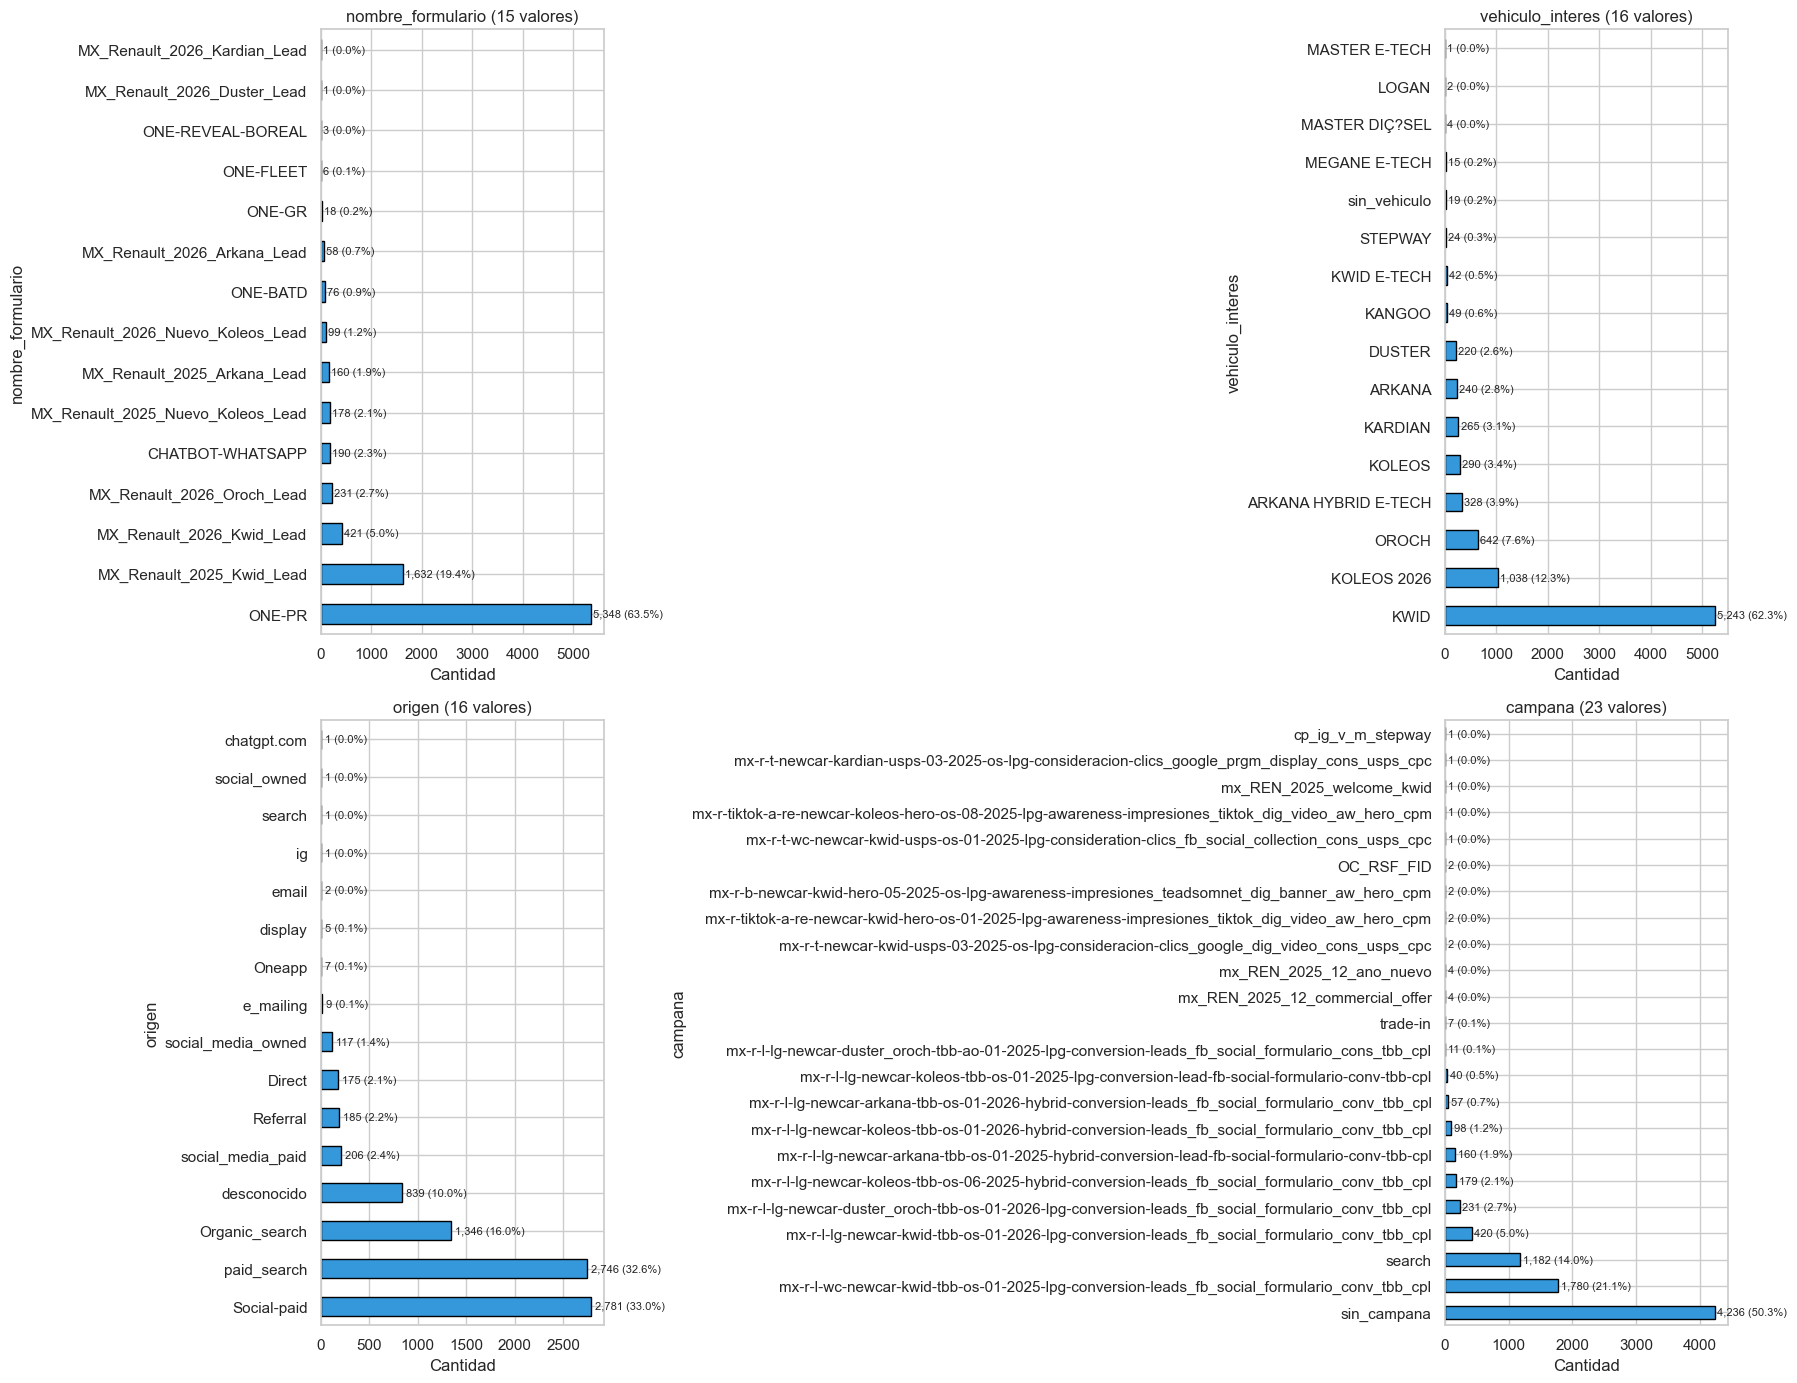

In [9]:
med_card = ["nombre_formulario", "vehiculo_interes", "origen", "campana"]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, col in zip(axes.flatten(), med_card):
    vc = df[col].value_counts()
    vc.plot(kind="barh", color="#3498db", edgecolor="black", ax=ax)
    ax.set_title(f"{col} ({len(vc)} valores)")
    ax.set_xlabel("Cantidad")
    for i, (val, cnt) in enumerate(vc.items()):
        ax.text(cnt + len(df)*0.005, i, f"{cnt:,} ({cnt/len(df)*100:.1f}%)", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 Concesión (alta cardinalidad — 93 valores)

Con 93 concesionarios, mostramos solo los **Top 20** por volumen. Las concesiones con muy pocos registros podrían generar ruido en el modelo.

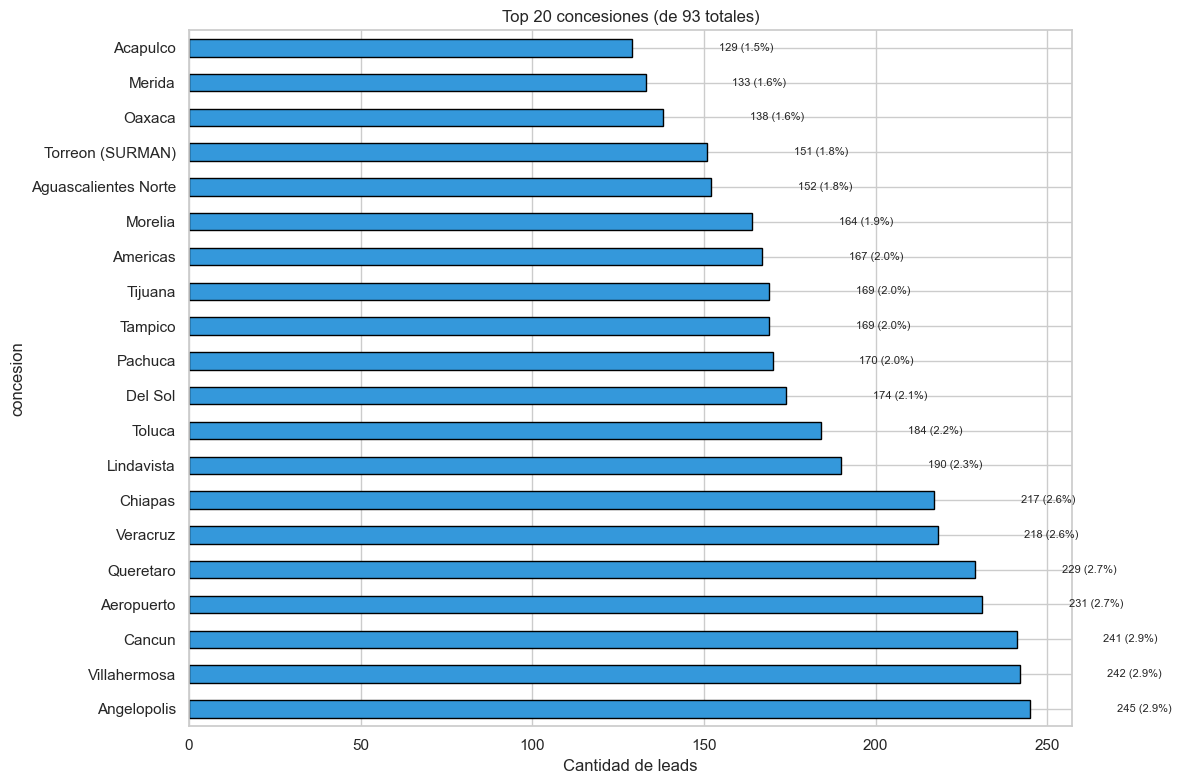


Concentración de concesiones:
  Top 5 concentran:  14.1% de los leads
  Top 10 concentran: 25.8% de los leads
  Top 20 concentran: 44.1% de los leads
  Las 73 restantes: 55.9%


In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

top_concesion = df["concesion"].value_counts().head(20)
top_concesion.plot(kind="barh", color="#3498db", edgecolor="black", ax=ax)
ax.set_title(f"Top 20 concesiones (de {df['concesion'].nunique()} totales)")
ax.set_xlabel("Cantidad de leads")

for i, (val, cnt) in enumerate(top_concesion.items()):
    ax.text(cnt + len(df)*0.003, i, f"{cnt:,} ({cnt/len(df)*100:.1f}%)", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nConcentración de concesiones:")
top5_pct = df["concesion"].value_counts().head(5).sum() / len(df) * 100
top10_pct = df["concesion"].value_counts().head(10).sum() / len(df) * 100
top20_pct = df["concesion"].value_counts().head(20).sum() / len(df) * 100
print(f"  Top 5 concentran:  {top5_pct:.1f}% de los leads")
print(f"  Top 10 concentran: {top10_pct:.1f}% de los leads")
print(f"  Top 20 concentran: {top20_pct:.1f}% de los leads")
print(f"  Las {df['concesion'].nunique() - 20} restantes: {100-top20_pct:.1f}%")

### 4.4 Conclusiones del análisis categórico

1. **Plataforma:** El 60.7% de los leads pasaron por el chatbot (`MX_LEAD_CHATBOT_QUALIF`) y el 39.3% completaron el formulario manual (`MX_LEAD_QUALIF`). Esta feature podría ser predictiva si la tasa de conversión difiere entre ambas.

2. **Subtipo de interés:** Dominado casi totalmente por "Solicitud de compra" (96.5%). Las otras categorías tienen muy pocos registros (<210). Considerar agrupar las minoritarias o evaluar si esta feature aporta variabilidad suficiente para el modelo.

3. **Origen de creación:** ONE concentra el 64.7%, Facebook el 33%, WhatsApp apenas el 2.3%. Hay que ver si el canal impacta en la conversión.

4. **Vehículo de interés:** KWID domina con el 62.3% de los leads, seguido de KOLEOS 2026 (12.3%) y OROCH (7.6%). La concentración en KWID refleja que es el modelo más económico y popular.

5. **Nombre de formulario:** ONE-PR concentra el 63.5%. Hay 15 formularios distintos pero la mayoría del tráfico pasa por uno solo.

6. **Concesión (alta cardinalidad):** 93 concesionarios con distribución muy dispersa. El Top 5 solo concentra el 14.1% de los leads. Esto puede generar problemas con el encoding one-hot (demasiadas columnas). Considerar agrupar concesiones de bajo volumen en "otros" o usar target encoding.

7. **Campaña:** 23 campañas, pero "sin_campana" (nuestro valor imputado) es la más frecuente (50.3%). Las campañas activas tienen distribución variada.

**Recomendación para el modelo:** `subtipo_interes` tiene muy poca variabilidad (96.5% un solo valor) — evaluar si eliminarla. `concesion` requiere estrategia especial de encoding por su alta cardinalidad.

## 5. Tasa de conversión por feature (relación feature → target)

Este es el análisis más importante del EDA: **¿qué categorías convierten más que el promedio?**

Para cada feature categórica calculamos el **% de Hot Leads** por categoría y lo comparamos con el promedio global (68.7%). Las categorías que se alejan mucho del promedio son las más útiles para el modelo.

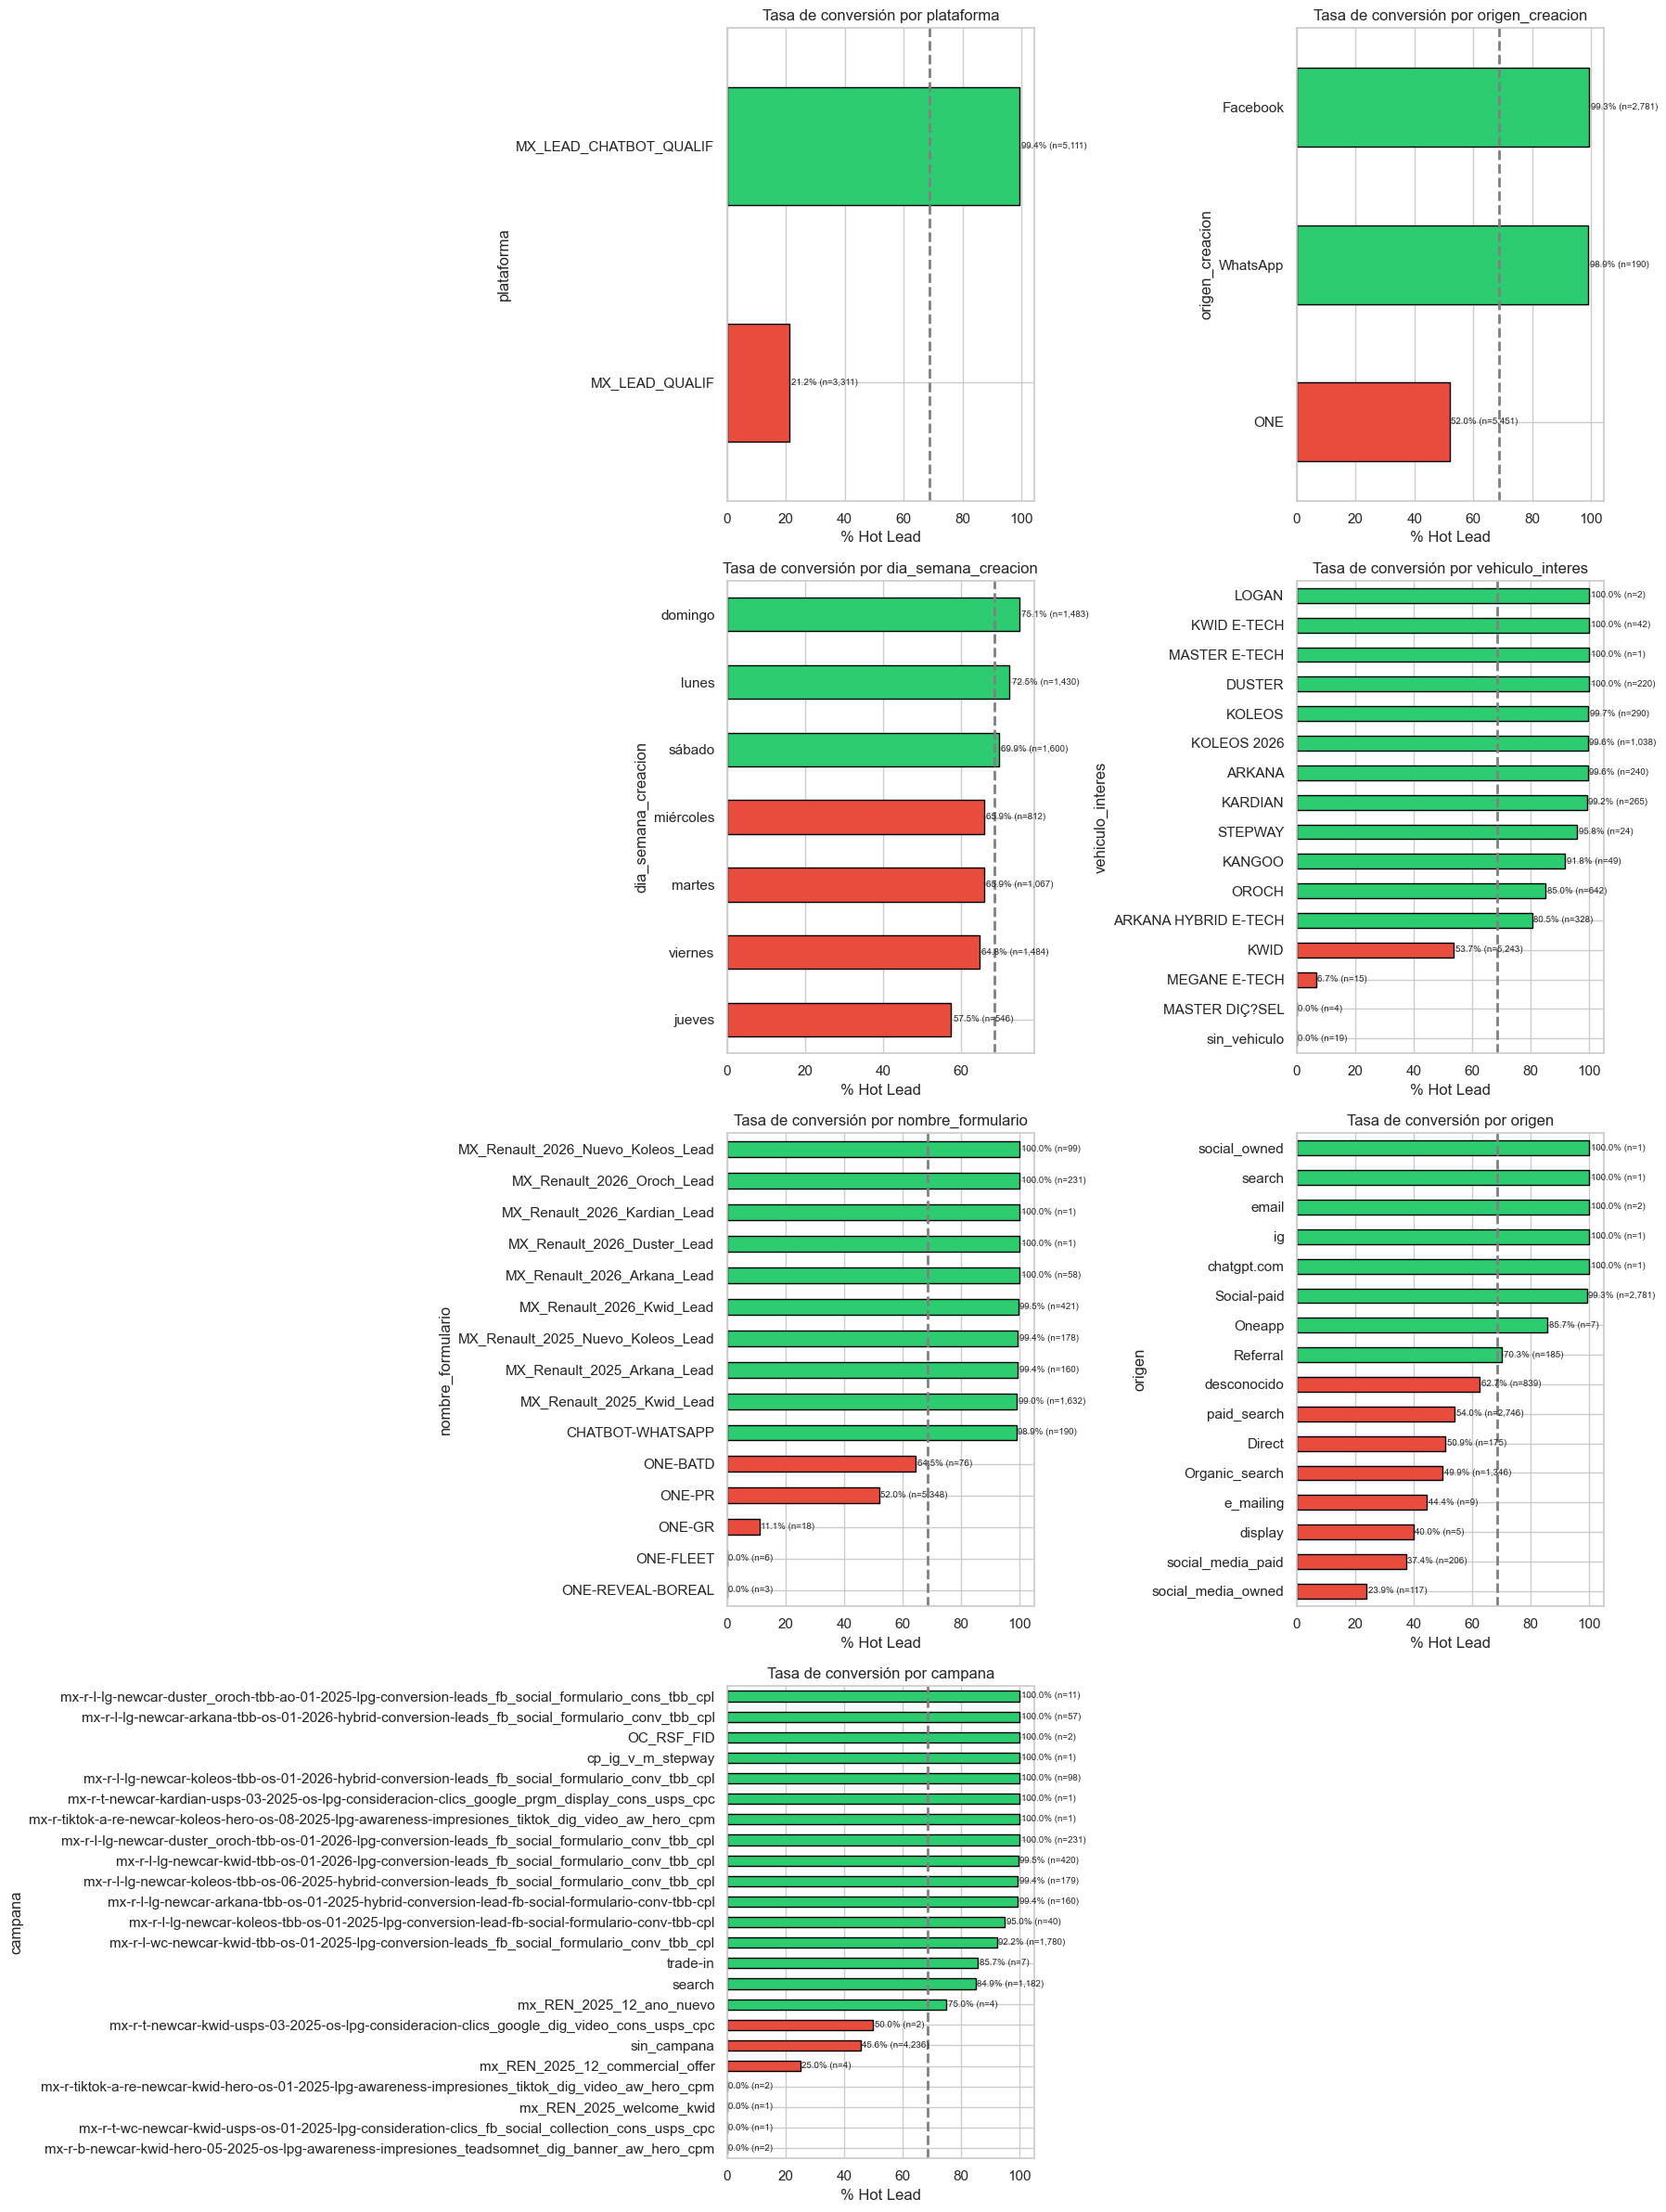

In [11]:
cat_features = ["plataforma", "origen_creacion", "dia_semana_creacion",
                "vehiculo_interes", "nombre_formulario", "origen", "campana"]
global_rate = df["target"].mean() * 100

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    conv = df.groupby(col)["target"].agg(["mean", "count"])
    conv["mean"] = conv["mean"] * 100
    conv = conv.sort_values("mean", ascending=True)
    
    colors = ["#2ecc71" if x >= global_rate else "#e74c3c" for x in conv["mean"]]
    conv["mean"].plot(kind="barh", color=colors, edgecolor="black", ax=axes[i])
    axes[i].axvline(x=global_rate, color="gray", linestyle="--", linewidth=2)
    axes[i].set_title(f"Tasa de conversión por {col}")
    axes[i].set_xlabel("% Hot Lead")
    
    for j, (idx, row) in enumerate(conv.iterrows()):
        axes[i].text(row["mean"] + 0.5, j, f"{row['mean']:.1f}% (n={int(row['count']):,})",
                     va="center", fontsize=7)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [12]:
print("=== RESUMEN: FEATURES CON MAYOR PODER DISCRIMINATIVO ===\n")
print(f"Tasa de conversión global: {global_rate:.1f}%\n")

for col in cat_features:
    conv = df.groupby(col)["target"].mean() * 100
    rango = conv.max() - conv.min()
    mejor = conv.idxmax()
    peor = conv.idxmin()
    print(f"  {col:25s} | Rango: {rango:5.1f}pp | Mejor: {mejor} ({conv.max():.1f}%) | Peor: {peor} ({conv.min():.1f}%)")

=== RESUMEN: FEATURES CON MAYOR PODER DISCRIMINATIVO ===

Tasa de conversión global: 68.7%

  plataforma                | Rango:  78.1pp | Mejor: MX_LEAD_CHATBOT_QUALIF (99.4%) | Peor: MX_LEAD_QUALIF (21.2%)
  origen_creacion           | Rango:  47.3pp | Mejor: Facebook (99.3%) | Peor: ONE (52.0%)
  dia_semana_creacion       | Rango:  17.5pp | Mejor: domingo (75.1%) | Peor: jueves (57.5%)
  vehiculo_interes          | Rango: 100.0pp | Mejor: DUSTER (100.0%) | Peor: MASTER DIÇ?SEL (0.0%)
  nombre_formulario         | Rango: 100.0pp | Mejor: MX_Renault_2026_Arkana_Lead (100.0%) | Peor: ONE-FLEET (0.0%)
  origen                    | Rango:  76.1pp | Mejor: chatgpt.com (100.0%) | Peor: social_media_owned (23.9%)
  campana                   | Rango: 100.0pp | Mejor: OC_RSF_FID (100.0%) | Peor: mx-r-b-newcar-kwid-hero-05-2025-os-lpg-awareness-impresiones_teadsomnet_dig_banner_aw_hero_cpm (0.0%)


### 5.1 Tasa de conversión por concesión (Top 20)

Con 93 concesionarios, mostramos solo los 20 con mayor volumen para que el análisis sea representativo (las concesiones con pocos leads tienen tasas poco confiables).

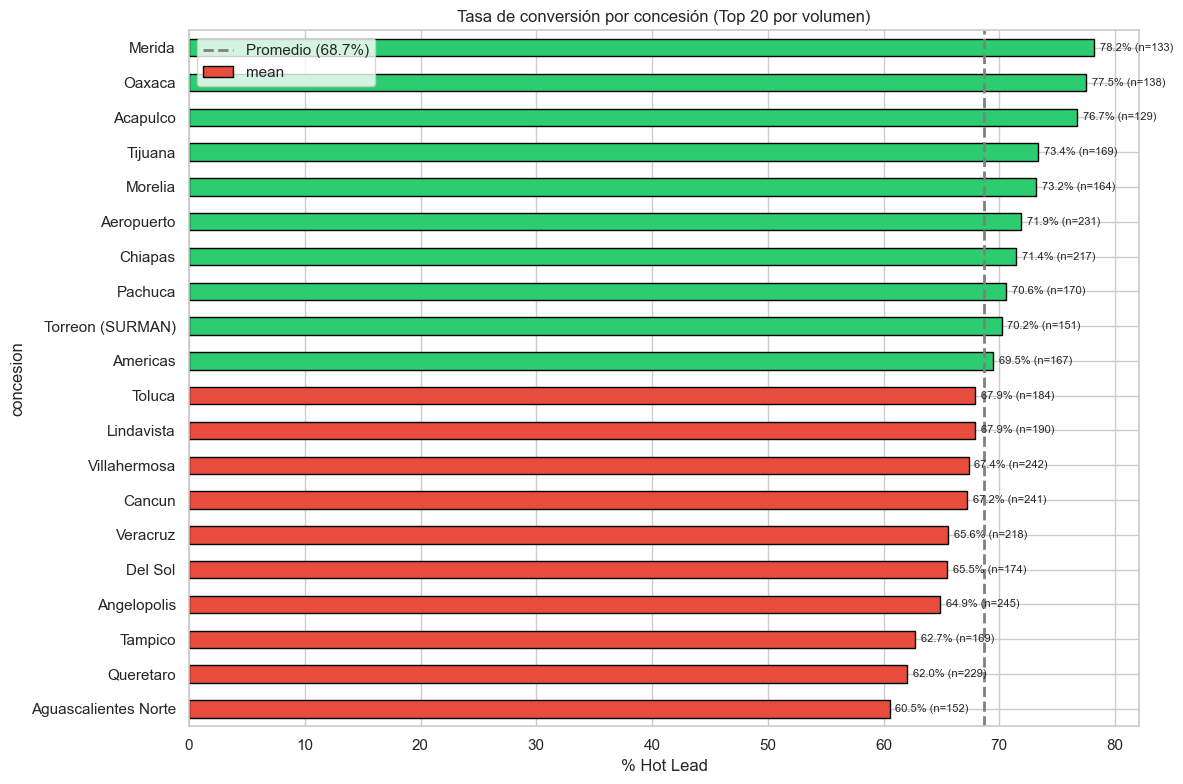

In [13]:
top20_names = df["concesion"].value_counts().head(20).index
df_top20 = df[df["concesion"].isin(top20_names)]

conv_conc = df_top20.groupby("concesion")["target"].agg(["mean", "count"])
conv_conc["mean"] = conv_conc["mean"] * 100
conv_conc = conv_conc.sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#2ecc71" if x >= global_rate else "#e74c3c" for x in conv_conc["mean"]]
conv_conc["mean"].plot(kind="barh", color=colors, edgecolor="black", ax=ax)
ax.axvline(x=global_rate, color="gray", linestyle="--", linewidth=2, label=f"Promedio ({global_rate:.1f}%)")
ax.set_title("Tasa de conversión por concesión (Top 20 por volumen)")
ax.set_xlabel("% Hot Lead")
ax.legend()

for j, (idx, row) in enumerate(conv_conc.iterrows()):
    ax.text(row["mean"] + 0.5, j, f"{row['mean']:.1f}% (n={int(row['count']):,})", va="center", fontsize=8)

plt.tight_layout()
plt.show()

### 5.2 Conclusiones de tasa de conversión

Los hallazgos se completarán con los datos reales al ejecutar. Puntos a evaluar:
- ¿Qué feature tiene el **mayor rango** entre su mejor y peor categoría? Esa feature es la más discriminativa.
- ¿Hay categorías con conversión muy por debajo del promedio? Son patrones que el modelo puede aprender.
- ¿La plataforma (bot vs manual) marca diferencia significativa?

## 6. Análisis temporal detallado (Heatmaps hora × día)

Los heatmaps permiten ver la interacción entre **dos features temporales simultáneamente**. Si ciertas combinaciones (ej: domingo a las 3am) tienen conversión muy diferente al promedio, eso es información valiosa para el modelo.

Generamos dos heatmaps:
1. **Volumen de leads** por hora × día de semana
2. **Tasa de conversión** por hora × día de semana

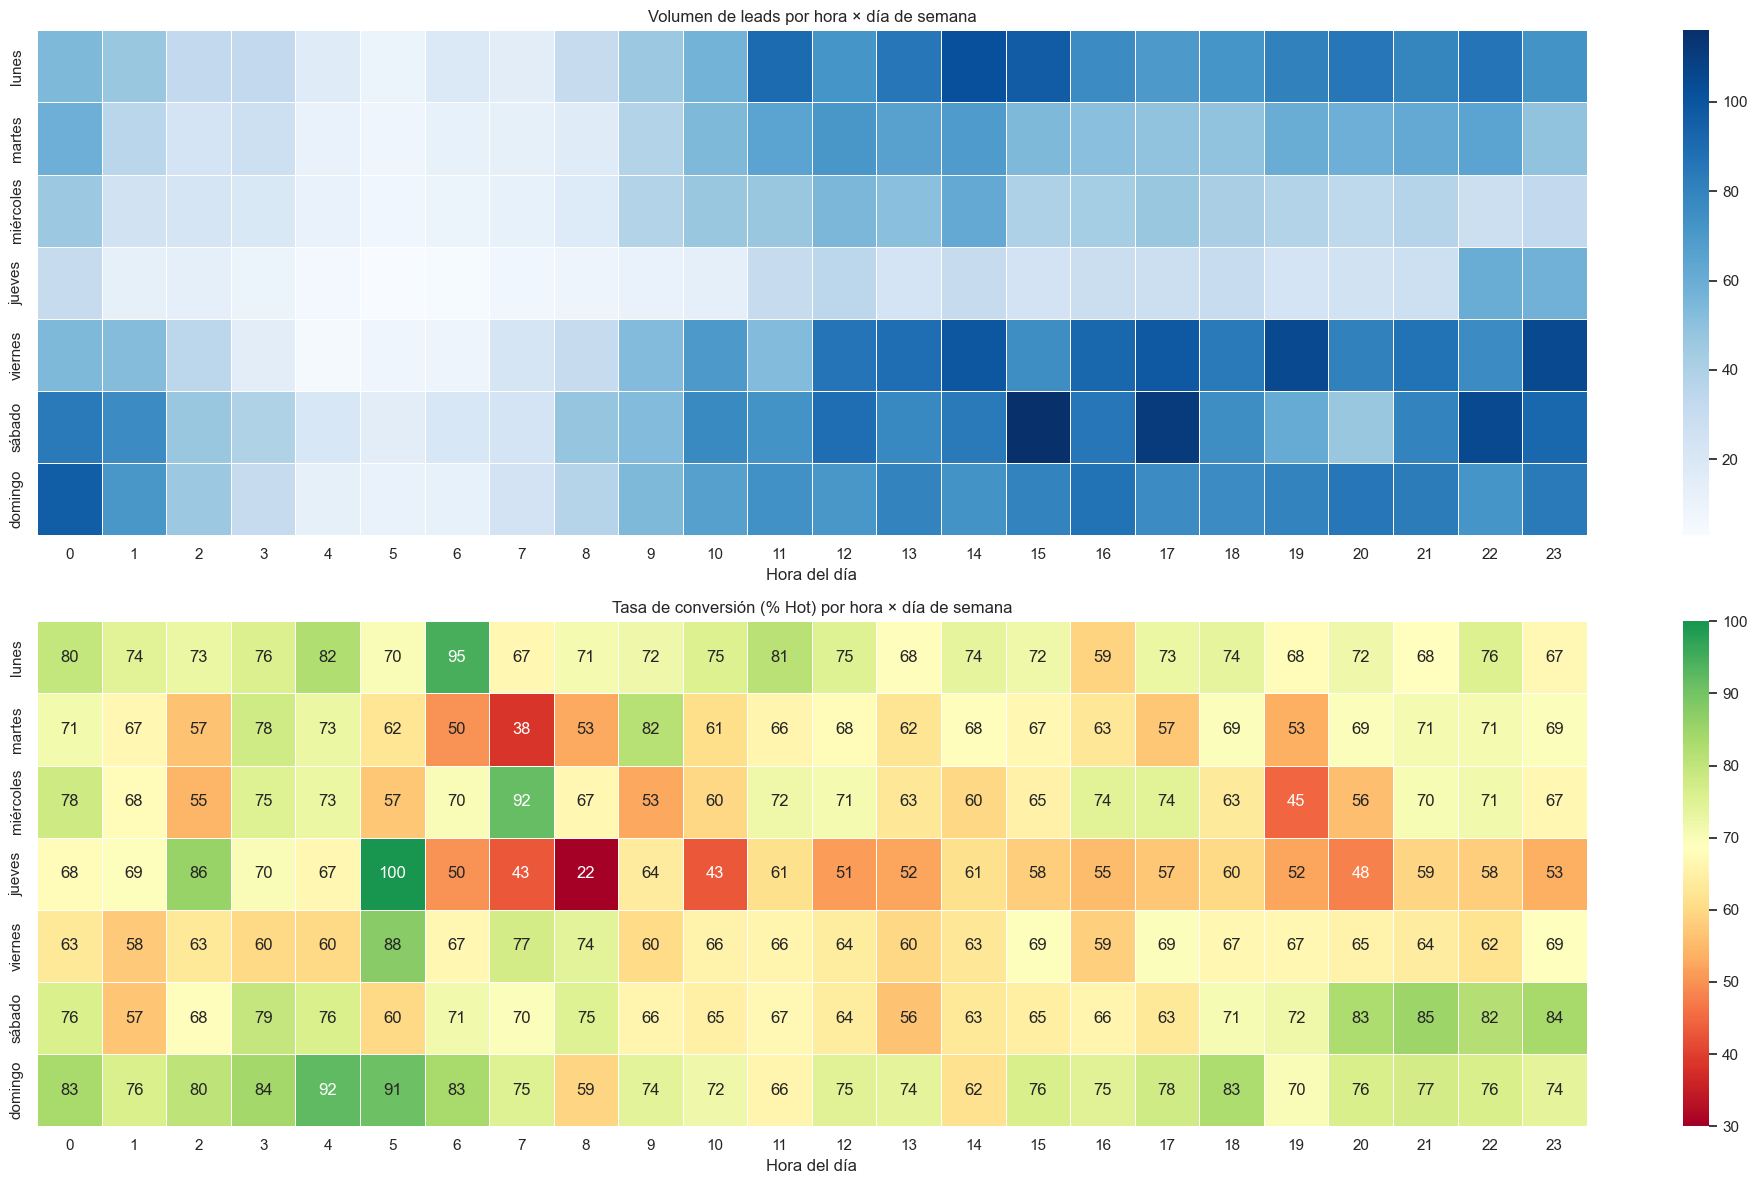

Combinaciones con MAYOR conversión (>80%, mínimo 20 leads):
  lunes        11:00 → 81.1% Hot (90 leads)
  martes       09:00 → 81.6% Hot (38 leads)
  sábado       20:00 → 83.0% Hot (47 leads)
  sábado       21:00 → 85.0% Hot (80 leads)
  sábado       22:00 → 81.9% Hot (105 leads)
  sábado       23:00 → 83.7% Hot (92 leads)
  domingo      00:00 → 83.3% Hot (96 leads)
  domingo      02:00 → 80.4% Hot (46 leads)
  domingo      03:00 → 83.9% Hot (31 leads)
  domingo      18:00 → 82.9% Hot (76 leads)

Combinaciones con MENOR conversión (<55%, mínimo 20 leads):
  martes       19:00 → 53.3% Hot (60 leads)
  miércoles    02:00 → 54.5% Hot (22 leads)
  miércoles    09:00 → 52.6% Hot (38 leads)
  miércoles    19:00 → 44.7% Hot (38 leads)
  jueves       12:00 → 51.4% Hot (35 leads)
  jueves       13:00 → 52.2% Hot (23 leads)
  jueves       19:00 → 52.2% Hot (23 leads)
  jueves       20:00 → 48.0% Hot (25 leads)
  jueves       23:00 → 53.4% Hot (58 leads)


In [14]:
orden_dias = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

pivot_vol = df.groupby(["dia_semana_creacion", "hora_creacion"]).size().unstack(fill_value=0)
pivot_vol = pivot_vol.reindex(orden_dias)

pivot_conv = df.groupby(["dia_semana_creacion", "hora_creacion"])["target"].mean().unstack(fill_value=0) * 100
pivot_conv = pivot_conv.reindex(orden_dias)

fig, axes = plt.subplots(2, 1, figsize=(20, 12))

sns.heatmap(pivot_vol, cmap="Blues", annot=False, fmt="d", linewidths=0.5, ax=axes[0])
axes[0].set_title("Volumen de leads por hora × día de semana")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("")

sns.heatmap(pivot_conv, cmap="RdYlGn", annot=True, fmt=".0f", linewidths=0.5,
            center=df["target"].mean()*100, ax=axes[1], vmin=30, vmax=100)
axes[1].set_title("Tasa de conversión (% Hot) por hora × día de semana")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("Combinaciones con MAYOR conversión (>80%, mínimo 20 leads):")
for dia in orden_dias:
    for hora in range(24):
        subset = df[(df["dia_semana_creacion"]==dia) & (df["hora_creacion"]==hora)]
        if len(subset) >= 20:
            rate = subset["target"].mean() * 100
            if rate > 80:
                print(f"  {dia:12s} {hora:02d}:00 → {rate:.1f}% Hot ({len(subset)} leads)")

print("\nCombinaciones con MENOR conversión (<55%, mínimo 20 leads):")
for dia in orden_dias:
    for hora in range(24):
        subset = df[(df["dia_semana_creacion"]==dia) & (df["hora_creacion"]==hora)]
        if len(subset) >= 20:
            rate = subset["target"].mean() * 100
            if rate < 55:
                print(f"  {dia:12s} {hora:02d}:00 → {rate:.1f}% Hot ({len(subset)} leads)")

## 7. Análisis de volumen vs conversión

¿Las categorías con más volumen de leads convierten mejor o peor? Este análisis cruza **cantidad** con **calidad** para cada feature categórica. Un punto ideal sería alto volumen + alta conversión.

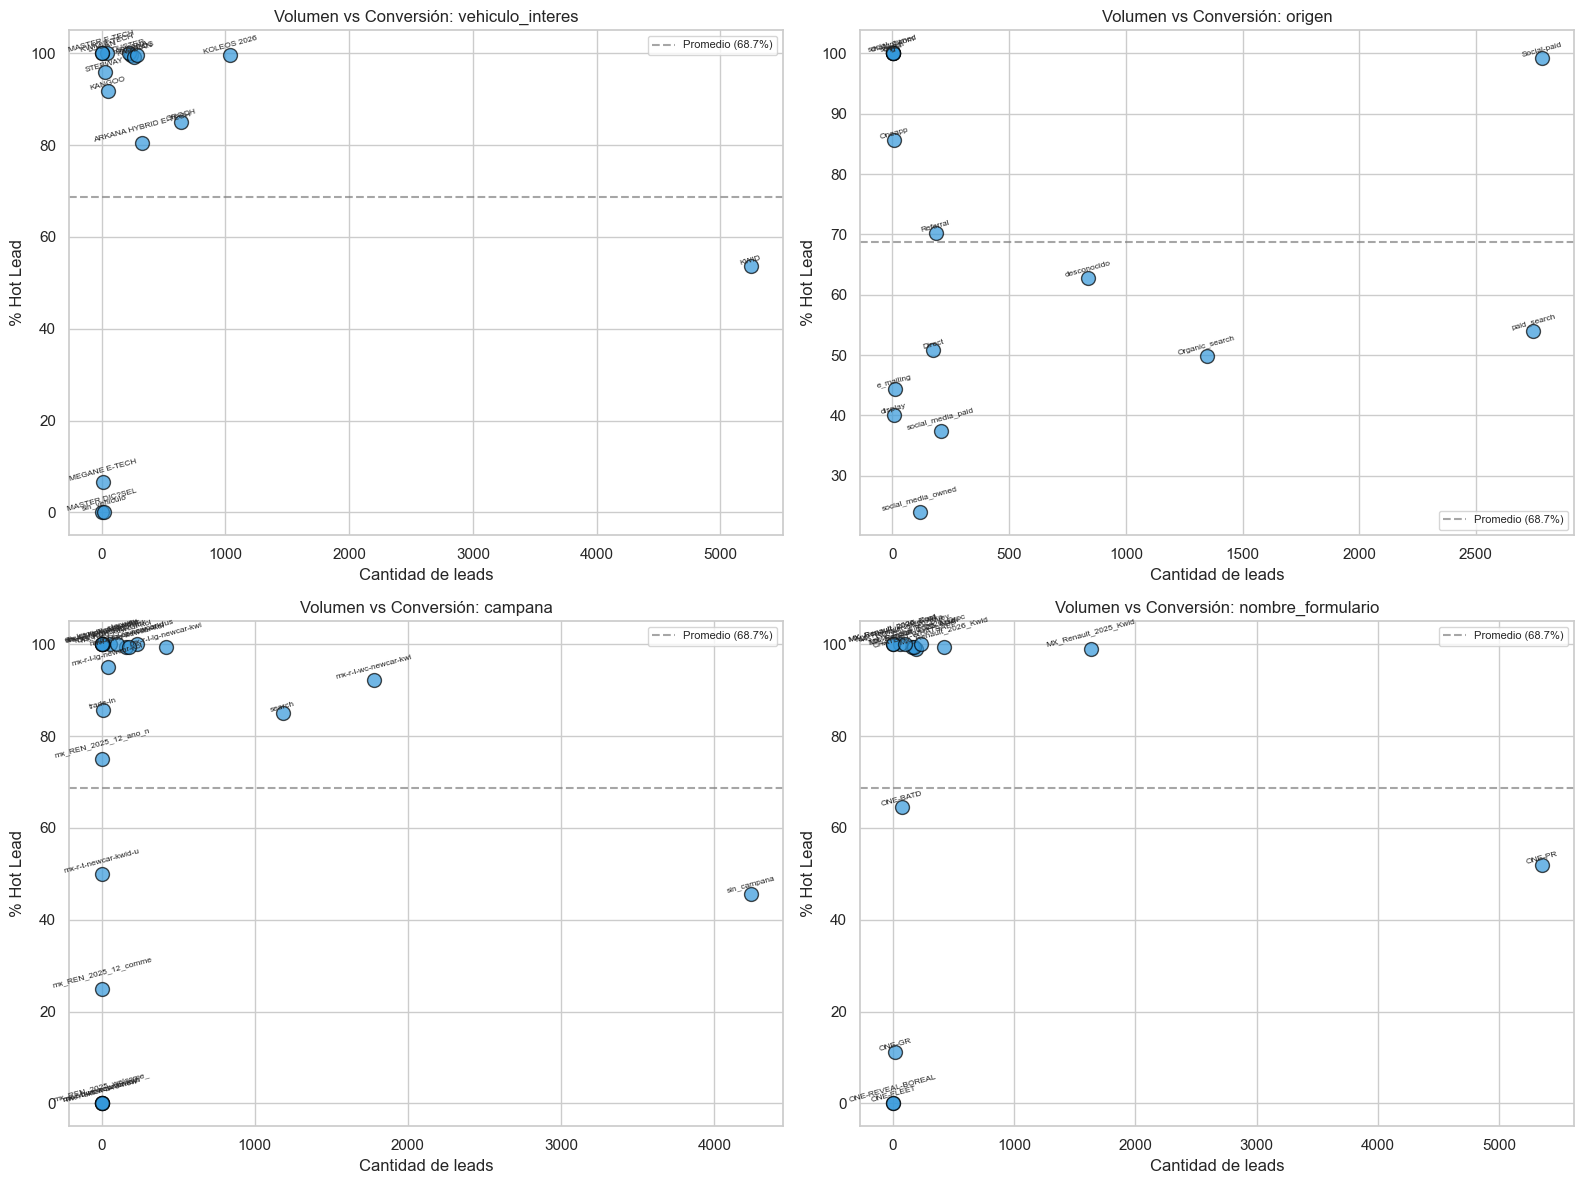

In [15]:
scatter_features = ["vehiculo_interes", "origen", "campana", "nombre_formulario"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, col in zip(axes.flatten(), scatter_features):
    stats = df.groupby(col)["target"].agg(["count", "mean"])
    stats["mean"] = stats["mean"] * 100

    ax.scatter(stats["count"], stats["mean"], s=100, alpha=0.7, edgecolors="black", c="#3498db")
    ax.axhline(y=global_rate, color="gray", linestyle="--", alpha=0.7, label=f"Promedio ({global_rate:.1f}%)")
    ax.set_title(f"Volumen vs Conversión: {col}")
    ax.set_xlabel("Cantidad de leads")
    ax.set_ylabel("% Hot Lead")
    ax.legend(fontsize=8)

    for idx, row in stats.iterrows():
        label = str(idx)[:20]
        ax.annotate(label, (row["count"], row["mean"]),
                    fontsize=6, ha="center", va="bottom", rotation=15)

plt.tight_layout()
plt.show()

In [16]:
print("=== ANÁLISIS VOLUMEN vs CONVERSIÓN ===\n")
print(f"{'Feature':25s} | {'Categoría':25s} | {'Volumen':>8s} | {'Conv %':>7s} | Clasificación")
print("-" * 100)

for col in scatter_features:
    stats = df.groupby(col)["target"].agg(["count", "mean"])
    stats["mean"] = stats["mean"] * 100
    median_vol = stats["count"].median()

    for idx, row in stats.sort_values("count", ascending=False).head(5).iterrows():
        alto_vol = "Alto vol" if row["count"] >= median_vol else "Bajo vol"
        alta_conv = "Alta conv" if row["mean"] >= global_rate else "Baja conv"
        clasificacion = f"{alto_vol} + {alta_conv}"
        label = str(idx)[:25]
        print(f"  {col:23s} | {label:25s} | {int(row['count']):>8,} | {row['mean']:>6.1f}% | {clasificacion}")

=== ANÁLISIS VOLUMEN vs CONVERSIÓN ===

Feature                   | Categoría                 |  Volumen |  Conv % | Clasificación
----------------------------------------------------------------------------------------------------
  vehiculo_interes        | KWID                      |    5,243 |   53.7% | Alto vol + Baja conv
  vehiculo_interes        | KOLEOS 2026               |    1,038 |   99.6% | Alto vol + Alta conv
  vehiculo_interes        | OROCH                     |      642 |   85.0% | Alto vol + Alta conv
  vehiculo_interes        | ARKANA HYBRID E-TECH      |      328 |   80.5% | Alto vol + Alta conv
  vehiculo_interes        | KOLEOS                    |      290 |   99.7% | Alto vol + Alta conv
  origen                  | Social-paid               |    2,781 |   99.3% | Alto vol + Alta conv
  origen                  | paid_search               |    2,746 |   54.0% | Alto vol + Baja conv
  origen                  | Organic_search            |    1,346 |   49.9% | Alto 

## 8. Correlaciones entre features numéricas

Analizamos la correlación entre las features numéricas y el target. Aunque nuestras features numéricas son temporales (y por lo tanto la correlación lineal de Pearson tiene limitaciones), este análisis nos da una primera aproximación.

También calculamos **Cramér's V** entre las features categóricas y el target para medir la asociación estadística de forma más apropiada.

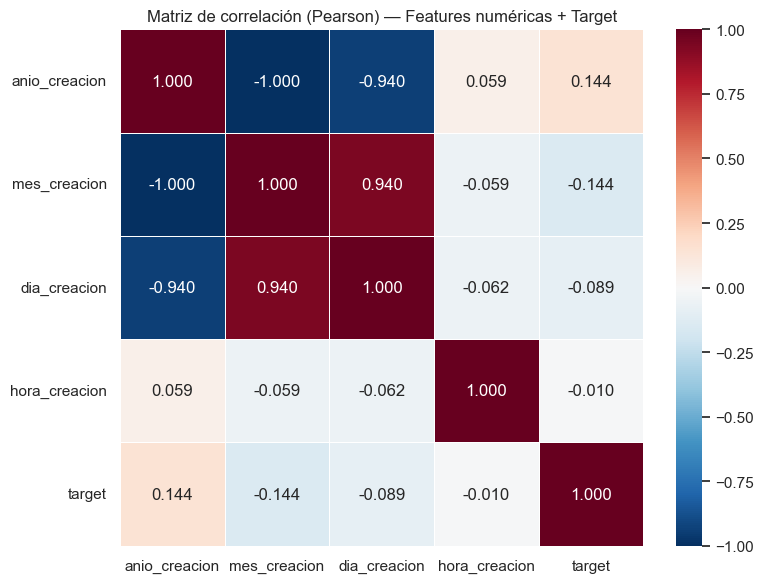

Correlación con el target:
  mes_creacion              → r = -0.144 (Moderada, negativa)
  anio_creacion             → r = +0.144 (Moderada, positiva)
  dia_creacion              → r = -0.089 (Débil, negativa)
  hora_creacion             → r = -0.010 (Débil, negativa)


In [24]:
num_cols = ["anio_creacion", "mes_creacion", "dia_creacion", "hora_creacion", "target"]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Matriz de correlación (Pearson) — Features numéricas + Target")
plt.tight_layout()
plt.show()

print("Correlación con el target:")
corr_target = corr_matrix["target"].drop("target").sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    fuerza = "Débil" if abs(val) < 0.1 else "Moderada" if abs(val) < 0.3 else "Fuerte"
    direccion = "positiva" if val > 0 else "negativa"
    print(f"  {feat:25s} → r = {val:+.3f} ({fuerza}, {direccion})")

In [25]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cat_cols = df.select_dtypes(include='object').columns.tolist()

print("=== CRAMÉR'S V (asociación feature categórica → target) ===\n")
print("Escala: 0 = sin asociación, 0.1-0.3 = débil, 0.3-0.5 = moderada, >0.5 = fuerte\n")

cramers = {}
for col in cat_cols:
    v = cramers_v(df[col], df["target"])
    cramers[col] = v

cramers_sorted = sorted(cramers.items(), key=lambda x: x[1], reverse=True)
for col, v in cramers_sorted:
    fuerza = "Débil" if v < 0.1 else "Moderada" if v < 0.3 else "Fuerte"
    barra = "█" * int(v * 50)
    print(f"  {col:25s} V = {v:.4f} ({fuerza:10s}) {barra}")

=== CRAMÉR'S V (asociación feature categórica → target) ===

Escala: 0 = sin asociación, 0.1-0.3 = débil, 0.3-0.5 = moderada, >0.5 = fuerte



NameError: name 'chi2_contingency' is not defined

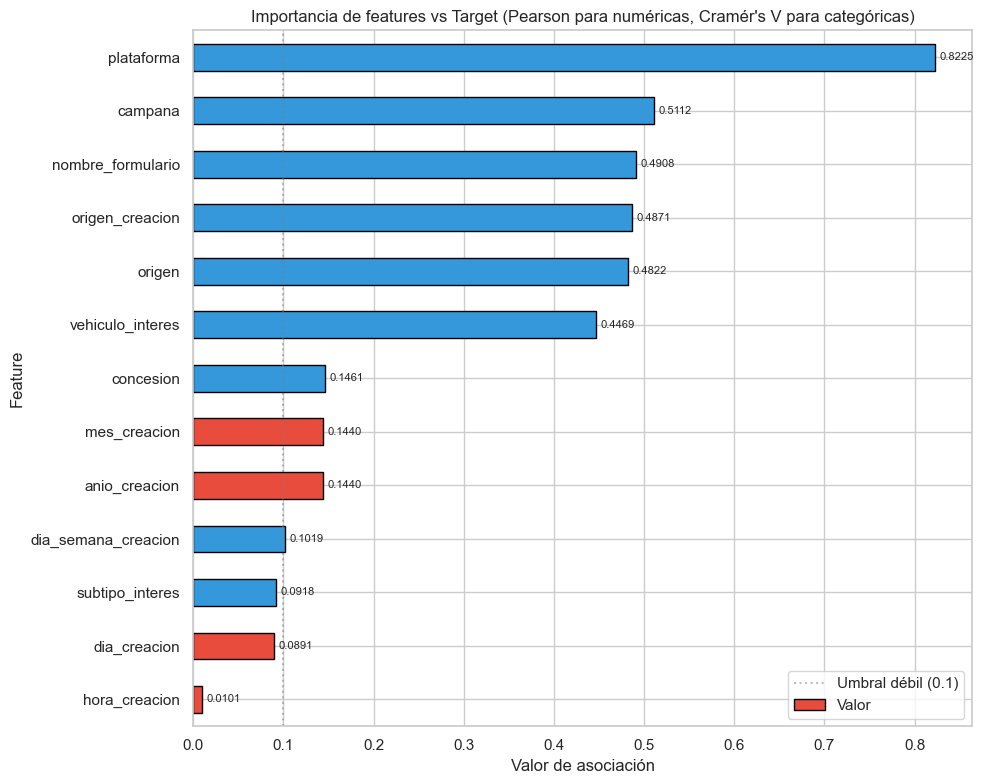

In [19]:
all_importance = []

for feat, val in corr_target.items():
    all_importance.append({"Feature": feat, "Métrica": "Pearson |r|", "Valor": abs(val), "Tipo": "Numérica"})

for col, v in cramers_sorted:
    all_importance.append({"Feature": col, "Métrica": "Cramér's V", "Valor": v, "Tipo": "Categórica"})

imp_df = pd.DataFrame(all_importance).sort_values("Valor", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if t == "Numérica" else "#3498db" for t in imp_df["Tipo"]]
imp_df.set_index("Feature")["Valor"].plot(kind="barh", color=colors, edgecolor="black", ax=ax)
ax.set_title("Importancia de features vs Target (Pearson para numéricas, Cramér's V para categóricas)")
ax.set_xlabel("Valor de asociación")
ax.axvline(x=0.1, color="gray", linestyle=":", alpha=0.5, label="Umbral débil (0.1)")
ax.legend()

for j, (idx, row) in enumerate(imp_df.iterrows()):
    ax.text(row["Valor"] + 0.005, j, f"{row['Valor']:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 9. Detección de categorías de baja frecuencia

Las categorías con muy pocos registros (<1% del total) pueden generar **ruido** en el modelo:
- El modelo no tiene suficientes ejemplos para aprender patrones reales
- Con one-hot encoding, crean columnas casi vacías
- Pueden causar sobreajuste

Identificamos estas categorías para decidir si agruparlas en "otros" durante el feature engineering.

In [20]:
UMBRAL_PCT = 1.0
umbral_abs = int(len(df) * UMBRAL_PCT / 100)

print(f"=== CATEGORÍAS DE BAJA FRECUENCIA (< {UMBRAL_PCT}% = {umbral_abs} leads) ===\n")

resumen_baja_freq = []

for col in cat_cols:
    vc = df[col].value_counts()
    bajas = vc[vc < umbral_abs]
    if len(bajas) > 0:
        pct_afectado = bajas.sum() / len(df) * 100
        print(f"  {col} ({len(vc)} categorías total, {len(bajas)} con baja frecuencia):")
        for cat, cnt in bajas.items():
            print(f"    - \"{cat}\": {cnt} leads ({cnt/len(df)*100:.2f}%)")
        print(f"    → Total afectado: {bajas.sum()} leads ({pct_afectado:.1f}%)\n")
        resumen_baja_freq.append({
            "Feature": col,
            "Total categorías": len(vc),
            "Baja frecuencia": len(bajas),
            "Leads afectados": bajas.sum(),
            "% afectado": pct_afectado
        })
    else:
        print(f"  {col}: Todas las categorías tienen >= {umbral_abs} leads \u2713\n")

if resumen_baja_freq:
    print("\n=== RESUMEN ===")
    res_df = pd.DataFrame(resumen_baja_freq).sort_values("Baja frecuencia", ascending=False)
    print(res_df.to_string(index=False))

=== CATEGORÍAS DE BAJA FRECUENCIA (< 1.0% = 84 leads) ===

  dia_semana_creacion: Todas las categorías tienen >= 84 leads ✓

  nombre_formulario (15 categorías total, 7 con baja frecuencia):
    - "ONE-BATD": 76 leads (0.90%)
    - "MX_Renault_2026_Arkana_Lead": 58 leads (0.69%)
    - "ONE-GR": 18 leads (0.21%)
    - "ONE-FLEET": 6 leads (0.07%)
    - "ONE-REVEAL-BOREAL": 3 leads (0.04%)
    - "MX_Renault_2026_Duster_Lead": 1 leads (0.01%)
    - "MX_Renault_2026_Kardian_Lead": 1 leads (0.01%)
    → Total afectado: 163 leads (1.9%)

  campana (23 categorías total, 15 con baja frecuencia):
    - "mx-r-l-lg-newcar-arkana-tbb-os-01-2026-hybrid-conversion-leads_fb_social_formulario_conv_tbb_cpl": 57 leads (0.68%)
    - "mx-r-l-lg-newcar-koleos-tbb-os-01-2025-lpg-conversion-lead-fb-social-formulario-conv-tbb-cpl": 40 leads (0.47%)
    - "mx-r-l-lg-newcar-duster_oroch-tbb-ao-01-2025-lpg-conversion-leads_fb_social_formulario_cons_tbb_cpl": 11 leads (0.13%)
    - "trade-in": 7 leads (0.08%)
   

## 10. Hallazgos clave y recomendaciones para el modelado

Resumen ejecutivo de todo el EDA con las decisiones que tomaremos en el feature engineering y modelado.

In [21]:
print("="*80)
print("   HALLAZGOS CLAVE DEL EDA")
print("="*80)

print("\n1. TARGET")
print(f"   - Distribución: {hot/total*100:.1f}% Hot / {cold/total*100:.1f}% Cold (ratio {ratio:.2f}:1)")
print("   - Desbalance leve, manejable sin técnicas especiales")
print("   - Monitorear recall de la clase minoritaria (Cold)")

print("\n2. FEATURES TEMPORALES")
print("   - hora_creacion: Madrugada (00-06h) convierte ~73-77%, horario laboral ~63-65%")
print("   - dia_semana_creacion: Domingo 75.1% vs Jueves 57.5% (17.6pp de diferencia)")
print("   - mes_creacion: Enero 80.4% vs Diciembre 64.8% (efecto patente año nuevo)")
print("   - anio_creacion: Solo 2 valores, poca variabilidad → CANDIDATA A ELIMINAR")

print("\n3. FEATURES CATEGÓRICAS CON MAYOR PODER DISCRIMINATIVO")
for col, v in cramers_sorted[:5]:
    print(f"   - {col}: Cramér's V = {v:.4f}")

print("\n4. FEATURES PROBLEMÁTICAS")
print("   - subtipo_interes: 96.5% un solo valor → CANDIDATA A ELIMINAR")
print("   - concesion: 93 valores, Top 5 solo 14.1% → REQUIERE TARGET ENCODING")
print("   - anio_creacion: Solo 2 valores (2025/2026) → CANDIDATA A ELIMINAR")

print("\n5. CATEGORÍAS DE BAJA FRECUENCIA")
if resumen_baja_freq:
    for r in resumen_baja_freq:
        print(f"   - {r['Feature']}: {r['Baja frecuencia']} categorías con <1% del total")
else:
    print("   - Ninguna feature tiene categorías con <1% del total")

print("\n" + "="*80)
print("   RECOMENDACIONES PARA FEATURE ENGINEERING")
print("="*80)
print("\n  1. ELIMINAR: anio_creacion (poca variabilidad)")
print("  2. EVALUAR ELIMINAR: subtipo_interes (96.5% un solo valor)")
print("  3. TARGET ENCODING: concesion (93 valores, alta cardinalidad)")
print("  4. ONE-HOT ENCODING: plataforma, origen_creacion, dia_semana_creacion")
print("  5. AGRUPAR categorías de baja frecuencia en 'otros' donde aplique")
print("  6. FEATURE IMPORTANTE: hora_creacion (mayor discriminación temporal)")
print("  7. CONSIDERAR: crear feature binaria 'es_fin_de_semana' (sáb/dom vs lun-vie)")
print("  8. CONSIDERAR: crear feature 'franja_horaria' (madrugada/mañana/tarde/noche)")

   HALLAZGOS CLAVE DEL EDA

1. TARGET
   - Distribución: 68.7% Hot / 31.3% Cold (ratio 2.19:1)
   - Desbalance leve, manejable sin técnicas especiales
   - Monitorear recall de la clase minoritaria (Cold)

2. FEATURES TEMPORALES
   - hora_creacion: Madrugada (00-06h) convierte ~73-77%, horario laboral ~63-65%
   - dia_semana_creacion: Domingo 75.1% vs Jueves 57.5% (17.6pp de diferencia)
   - mes_creacion: Enero 80.4% vs Diciembre 64.8% (efecto patente año nuevo)
   - anio_creacion: Solo 2 valores, poca variabilidad → CANDIDATA A ELIMINAR

3. FEATURES CATEGÓRICAS CON MAYOR PODER DISCRIMINATIVO
   - plataforma: Cramér's V = 0.8225
   - campana: Cramér's V = 0.5112
   - nombre_formulario: Cramér's V = 0.4908
   - origen_creacion: Cramér's V = 0.4871
   - origen: Cramér's V = 0.4822

4. FEATURES PROBLEMÁTICAS
   - subtipo_interes: 96.5% un solo valor → CANDIDATA A ELIMINAR
   - concesion: 93 valores, Top 5 solo 14.1% → REQUIERE TARGET ENCODING
   - anio_creacion: Solo 2 valores (2025/2026)

---

**EDA completado.** Los hallazgos de este análisis serán la base para las decisiones de feature engineering en el siguiente notebook (`02_feature_engineering.ipynb`).